In [242]:
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

print("Pandas version:", pd.__version__)

file_path = "../data/raw/Online_Retail.csv"

df = pd.read_csv(file_path)

Pandas version: 3.0.5


In [243]:
print("Structural Information: ")
df.info()

print("Summary Statistics: ")
df.describe()

print(f"DataFrame shape: {df.shape}")

missing_customers = df['CustomerID'].isnull().sum()
print(f"Missing CustomerID count: {missing_customers} ({missing_customers / len(df):.2%})")

Structural Information: 
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB
Summary Statistics: 
DataFrame shape: (541909, 8)
Missing CustomerID count: 135080 (24.93%)


The percentage of the missing customer id is 24.93% which is high. Dropping 20& of the data distorts the overall busines metrics. Instead of dropping, I assigned a label "Guest" for guest transactions.

In [244]:
df['CustomerID'] = df['CustomerID'].fillna('guest_' + df['InvoiceNo'].astype(str))
print(f"Missing CustomerID count after filling: {df['CustomerID'].isnull().sum()}")

df_cleaned = df.copy()

df_cleaned['CustomerID'] = df_cleaned['CustomerID'].astype(str)

invalid_rows = (df_cleaned['Quantity'] <= 0) | (df_cleaned['UnitPrice'] <= 0)
print(f"Number of invalid rows: {invalid_rows.sum()}. These rows will be dropped because Quantity or UnitPrice is zero or negative.")

df_cleaned = df_cleaned[
    ~df_cleaned['InvoiceNo'].astype(str).str.startswith('C') &
    (df_cleaned['Quantity'] > 0) &
    (df_cleaned['UnitPrice'] > 0)
]

print(f"Shape after removing cancellations & invalid amounts: {df_cleaned.shape}. We have removed {len(df) - len(df_cleaned)} rows from the original dataset.")

df_cleaned['InvoiceDate'] = pd.to_datetime(df_cleaned['InvoiceDate'], format='%m/%d/%Y %H:%M')
df_cleaned['Year'] = df_cleaned['InvoiceDate'].dt.year
df_cleaned['Month'] = df_cleaned['InvoiceDate'].dt.month
df_cleaned['DayOfWeek'] = df_cleaned['InvoiceDate'].dt.day_name()

df_cleaned['TotalAmount'] = df_cleaned['Quantity'] * df_cleaned['UnitPrice']
df_cleaned[['InvoiceDate', 'Year', 'Month', 'DayOfWeek', 'Quantity', 'UnitPrice', 'TotalAmount']].head(10)

Missing CustomerID count after filling: 0
Number of invalid rows: 11805. These rows will be dropped because Quantity or UnitPrice is zero or negative.
Shape after removing cancellations & invalid amounts: (530104, 8). We have removed 11805 rows from the original dataset.


,InvoiceDate,Year,Month,DayOfWeek,Quantity,UnitPrice,TotalAmount
0,2010-12-01 08:26:00,2010,12,Wednesday,6,2.55,15.30
1,2010-12-01 08:26:00,2010,12,Wednesday,6,3.39,20.34
2,2010-12-01 08:26:00,2010,12,Wednesday,8,2.75,22.00
3,2010-12-01 08:26:00,2010,12,Wednesday,6,3.39,20.34
4,2010-12-01 08:26:00,2010,12,Wednesday,6,3.39,20.34
5,2010-12-01 08:26:00,2010,12,Wednesday,2,7.65,15.30
6,2010-12-01 08:26:00,2010,12,Wednesday,6,4.25,25.50
7,2010-12-01 08:28:00,2010,12,Wednesday,6,1.85,11.10
8,2010-12-01 08:28:00,2010,12,Wednesday,6,1.85,11.10
9,2010-12-01 08:34:00,2010,12,Wednesday,32,1.69,54.08


In [245]:
#KPI METRICS
total_line_items = len(df_cleaned)
total_revenue = df_cleaned['TotalAmount'].sum()
total_orders = df_cleaned['InvoiceNo'].nunique()
average_order_value = total_revenue / total_orders
unique_customers = df_cleaned['CustomerID'].nunique()
registered_orders = df_cleaned[~df_cleaned['CustomerID'].str.startswith('guest')]['InvoiceNo'].nunique()
total_units = df_cleaned['Quantity'].sum()
guest_orders = df_cleaned[df_cleaned['CustomerID'].str.startswith('guest')]['InvoiceNo'].nunique()
guest_share = (guest_orders / total_orders) * 100

print("KPI METRICS:")
print(f"Total Line Items: {total_line_items:,}")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Average Order Value: ${average_order_value:,.2f}")
print(f"Unique Customers: {unique_customers}")
print(f"Total Units Sold: {total_units}")
print(f"Registered Orders: {registered_orders:,} ({(registered_orders / total_orders):.2%})")
print(f"Guest Orders:      {guest_orders:,} ({(guest_orders / total_orders):.2%})")


KPI METRICS:
Total Line Items: 530,104
Total Revenue: $10,666,684.54
Total Orders: 19960
Average Order Value: $534.40
Unique Customers: 5766
Total Units Sold: 5588376
Registered Orders: 18,532 (92.85%)
Guest Orders:      1,428 (7.15%)


In [246]:
monthly_revenue = (
    df_cleaned.groupby(['Year', 'Month'])['TotalAmount']
    .sum()
    .reset_index()
    .rename(columns={'TotalAmount': 'Revenue'})
    )
monthly_revenue['Month'] = pd.to_datetime(monthly_revenue['Month'], format='%m').dt.month_name()

monthly_revenue.style.hide(axis='index').format({'Revenue': '${:,.2f}'})

Year,Month,Revenue
2010,December,"$823,746.14"
2011,January,"$691,364.56"
2011,February,"$523,631.89"
2011,March,"$717,639.36"
2011,April,"$537,808.62"
2011,May,"$770,536.02"
2011,June,"$761,739.90"
2011,July,"$719,221.19"
2011,August,"$759,138.38"
2011,September,"$1,058,590.17"


In [247]:
top_products = (
    df_cleaned.groupby('Description')['TotalAmount']
    .sum()
    .reset_index()
    .sort_values(by = 'TotalAmount', ascending = False)
    .head(10)
    .rename(columns={'TotalAmount': 'Revenue'})
)
print('TOP 10 PRODUCTS BY REVENUE')
top_products.style.hide(axis='index').format({'Revenue': '${:,.2f}'})

TOP 10 PRODUCTS BY REVENUE


Description,Revenue
DOTCOM POSTAGE,"$206,248.77"
REGENCY CAKESTAND 3 TIER,"$174,484.74"
"PAPER CRAFT , LITTLE BIRDIE","$168,469.60"
WHITE HANGING HEART T-LIGHT HOLDER,"$106,292.77"
PARTY BUNTING,"$99,504.33"
JUMBO BAG RED RETROSPOT,"$94,340.05"
MEDIUM CERAMIC TOP STORAGE JAR,"$81,700.92"
Manual,"$78,112.82"
POSTAGE,"$78,101.88"
RABBIT NIGHT LIGHT,"$66,964.99"


In [248]:
cutoff_date = df_cleaned['InvoiceDate'].max() + pd.Timedelta(days=1)
print (f"Analysis Cutoff Date: {cutoff_date.strftime('%Y-%m-%d')}")

Analysis Cutoff Date: 2011-12-10


In [249]:
customer_df = df_cleaned[~df_cleaned['CustomerID'].str.startswith('guest_')].copy()

recency_df = (
    customer_df
    .groupby('CustomerID')['InvoiceDate']
    .max()
    .reset_index()
)
recency_df['Recency'] = (cutoff_date - recency_df['InvoiceDate']).dt.days
recency_df = recency_df[['CustomerID', 'Recency']]

bins = [-1, 30, 90, 180, 365, 1000]
labels = ['Active (0-30d)', 'Warm (31-90d)', 'Cold (91-180d)', 'At Risk (181-365d)', 'Lapsed (365d+)']
recency_df['Recency_Segment'] = pd.cut(recency_df['Recency'], bins=bins, labels=labels)

segment_summary = (
    recency_df
    .groupby('Recency_Segment', observed=False)
    .agg(Customer_Count=('CustomerID', 'count'))
    .reset_index()
)
segment_summary['Share_%'] = (segment_summary['Customer_Count'] / len(recency_df)) * 100
segment_summary.style.hide(axis='index').format({'Share_%': '{:,.2f}%'})

Recency_Segment,Customer_Count,Share_%
Active (0-30d),1648,37.99%
Warm (31-90d),1241,28.61%
Cold (91-180d),589,13.58%
At Risk (181-365d),791,18.23%
Lapsed (365d+),69,1.59%


In [250]:
fm_df = (
    customer_df
    .groupby('CustomerID')
    .agg(
        Frequency=('InvoiceNo', 'nunique'),  # How often they purchase
        Monetary=('TotalAmount', 'sum')  # How much they spend
    )
    .reset_index()
)

rfm = pd.merge(recency_df, fm_df, on='CustomerID')

valuable_customers = rfm.sort_values(by='Monetary', ascending=False)

display(
    valuable_customers.head(10)
    .style.hide(axis='index')
    .format({
        'CustomerID': lambda x: str(x).replace('.0', ''),
        'Monetary': '${:,.2f}'
    })
)

CustomerID,Recency,Recency_Segment,Frequency,Monetary
14646,2,Active (0-30d),73,"$280,206.02"
18102,1,Active (0-30d),60,"$259,657.30"
17450,8,Active (0-30d),46,"$194,550.79"
16446,1,Active (0-30d),2,"$168,472.50"
14911,1,Active (0-30d),201,"$143,825.06"
12415,24,Active (0-30d),21,"$124,914.53"
14156,10,Active (0-30d),55,"$117,379.63"
17511,3,Active (0-30d),31,"$91,062.38"
16029,39,Warm (31-90d),63,"$81,024.84"
12346,326,At Risk (181-365d),1,"$77,183.60"


In [251]:

rfm['Frequency_Log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_Log'] = np.log1p(rfm['Monetary'])

# Check skewness values before and after
print("--- SKEWNESS COMPARISON ---")
print("Original Skewness:")
print(rfm[['Frequency', 'Monetary']].skew())

print("\nLog-Transformed Skewness:")
print(rfm[[ 'Frequency_Log', 'Monetary_Log']].skew())

# View updated table
display(rfm.head())

--- SKEWNESS COMPARISON ---
Original Skewness:
Frequency    12.067031
Monetary     19.324953
dtype: float64

Log-Transformed Skewness:
Frequency_Log    1.208652
Monetary_Log     0.393553
dtype: float64


,CustomerID,Recency,Recency_Segment,Frequency,Monetary,Frequency_Log,Monetary_Log
0,12346.0,326,At Risk (181-365d),1,77183.60,0.693147,11.253955
1,12347.0,2,Active (0-30d),7,4310.00,2.079442,8.368925
2,12348.0,75,Warm (31-90d),4,1797.24,1.609438,7.494564
3,12349.0,19,Active (0-30d),1,1757.55,0.693147,7.472245
4,12350.0,310,At Risk (181-365d),1,334.40,0.693147,5.815324


In [252]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm[[ 'Frequency_Log', 'Monetary_Log']])

Testing K values from 2 to 8...
K = 2 | Silhouette Score: 0.5286
K = 3 | Silhouette Score: 0.4591
K = 4 | Silhouette Score: 0.4233
K = 5 | Silhouette Score: 0.3820
K = 6 | Silhouette Score: 0.3715
K = 7 | Silhouette Score: 0.3731
K = 8 | Silhouette Score: 0.3980


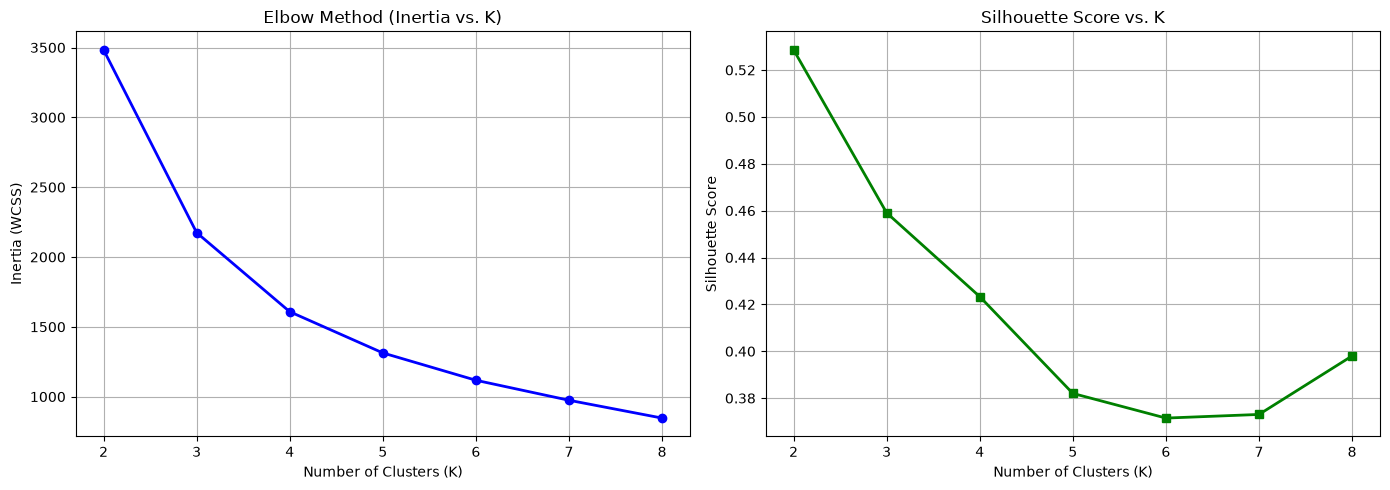

In [253]:
# Evaluate candidate cluster counts

inertia_list = []
silhouette_list = []
k_range = range(2, 9)  # Testing cluster sizes K = 2 through 8

print("Testing K values from 2 to 8...")
for k in k_range:
  kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
  cluster_labels = kmeans_test.fit_predict(rfm_scaled)

  # Calculate metrics
  inertia_list.append(kmeans_test.inertia_)
  score = silhouette_score(rfm_scaled, cluster_labels)
  silhouette_list.append(score)
  print(f"K = {k} | Silhouette Score: {score:.4f}")

# Plotting Elbow Curve and Silhouette Scores side-by-side
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Elbow Curve
ax[0].plot(k_range, inertia_list, marker="o", color="b", linewidth=2)
ax[0].set_title("Elbow Method (Inertia vs. K)", fontsize=12)
ax[0].set_xlabel("Number of Clusters (K)")
ax[0].set_ylabel("Inertia (WCSS)")
ax[0].grid(True)

# Plot 2: Silhouette Scores
ax[1].plot(k_range, silhouette_list, marker="s", color="green", linewidth=2)
ax[1].set_title("Silhouette Score vs. K", fontsize=12)
ax[1].set_xlabel("Number of Clusters (K)")
ax[1].set_ylabel("Silhouette Score")
ax[1].grid(True)

plt.tight_layout()
plt.show()

optimal_k = 3 # Combining both metrics, $K = 3$ is likely the best choice because it hits a strong inflection point on the elbow curve while maintaining a near-peak Silhouette Score (~0.487).



In [254]:
# Train the final K-Means model and assign customer clusters
optimal_k = 3

kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm["Cluster"] = kmeans_model.fit_predict(rfm_scaled)


In [255]:
# Segment labels are based on the cluster mean metrics below
segment_map = {
    0: 'Lapsed / Low-Value',
    1: 'Champions / High-Value',
    2: 'Occasional / Mid-Value',
}

rfm['Segment_Name'] = rfm['Cluster'].map(segment_map)

cluster_summary = (
    rfm.groupby('Segment_Name')
    .agg(
        Recency=('Recency', 'mean'),
        Frequency=('Frequency', 'mean'),
        Monetary=('Monetary', 'mean'),
        Customer_Count=('Segment_Name', 'count'),
    )
    .round(2)
)

print('CLUSTER MEAN METRICS')
print(cluster_summary)

CLUSTER MEAN METRICS
                        Recency  Frequency  Monetary  Customer_Count
Segment_Name                                                        
Champions / High-Value    23.74      13.77   8357.83             738
Lapsed / Low-Value       142.32       1.28    294.53            1875
Occasional / Mid-Value    67.86       3.47   1270.20            1725


In [256]:
os.makedirs("models", exist_ok=True)

# Save the scaler and model
joblib.dump(scaler, "models/scaler.joblib")
joblib.dump(kmeans_model, "models/kmeans_model.joblib")

print(
    "Saved 'scaler.joblib' and 'kmeans_model.joblib' in 'models/' directory."
)

Saved 'scaler.joblib' and 'kmeans_model.joblib' in 'models/' directory.
